In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install gensim

<h2>1. Data Loading </h2>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '/content/drive/MyDrive/Colab_Objects/data/unisa_undergrad_qualif_2024_12_03_08_21_32.csv'
df = pd.read_csv(file_path)
df.head()

,name,code,saqa_id,dep,aps,faculty,nqf,credits,desc,comments,school,url
0,Higher Certificate in Banking (98225),98225,84286,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The primary purpose of the q...,\nRules:\nStudents who have already passed BAN...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...
1,Higher Certificate in Economic and Management ...,98237,90677,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The purpose of this qualific...,\nRules:Students should note that during the c...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...
2,Higher Certificate in Marketing (98229),98229,84766,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The primary purpose of this ...,\nRules:\nThe College has replaced EUP1501 wit...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...
3,Higher Certificate in Retailing (90014),90014,94791,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The purpose of the qualifica...,\nRules:\nStudents who have already passed MNM...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...
4,Higher Certificate in Supervisory Management (...,90015,94630,NaN,15,Economic and Management Sciences,5,120,Purpose statement:The purpose of this qualific...,\nRules:\nStudents should note that during the...,NaN,https://www.unisa.ac.za/sites/corporate/defaul...


In [ ]:
df['faculty'].unique()

array(['Economic and Management Sciences', 'Accounting Sciences',
       'Agriculture and Environmental Sciences', 'Education',
       'Human Sciences', 'Law', 'Science, Engineering and Technology'],
      dtype=object)

<h2>2. Raw Feature Matrix Collection </h2>

In [ ]:
features_df = df.loc[:,['desc','comments','code','name','faculty']]
features_df['features'] = features_df['desc']+' '+features_df['comments']+' '+features_df['name']
features_df.head()

,desc,comments,code,name,faculty,features
0,Purpose statement:The primary purpose of the q...,\nRules:\nStudents who have already passed BAN...,98225,Higher Certificate in Banking (98225),Economic and Management Sciences,Purpose statement:The primary purpose of the q...
1,Purpose statement:The purpose of this qualific...,\nRules:Students should note that during the c...,98237,Higher Certificate in Economic and Management ...,Economic and Management Sciences,Purpose statement:The purpose of this qualific...
2,Purpose statement:The primary purpose of this ...,\nRules:\nThe College has replaced EUP1501 wit...,98229,Higher Certificate in Marketing (98229),Economic and Management Sciences,Purpose statement:The primary purpose of this ...
3,Purpose statement:The purpose of the qualifica...,\nRules:\nStudents who have already passed MNM...,90014,Higher Certificate in Retailing (90014),Economic and Management Sciences,Purpose statement:The purpose of the qualifica...
4,Purpose statement:The purpose of this qualific...,\nRules:\nStudents should note that during the...,90015,Higher Certificate in Supervisory Management (...,Economic and Management Sciences,Purpose statement:The purpose of this qualific...


<h2>3. Preprocessing </h2>

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    # Tokenize the text
    words = word_tokenize(text)
    # Get the list of English stopwords
    stop_words = set(stopwords.words('english'))
    # Remove stopwords
    filtered_words = [word for word in words if word.lower() not in stop_words]
    # Join the filtered words back into a string
    text = ' '.join(filtered_words)
    comments_words = ['purpose','may','required','skills','students','level','subject','internet','statement','rules','qualification']
    for word in comments_words:
        text = text.replace(word,'')
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip()
    clean_text = text
    return clean_text

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
features_df['features'] = features_df['features'].apply(preprocess)
features_df[['features','faculty','code']].head()

,features,faculty,code
0,primary closely tied rationale introduce learn...,Economic and Management Sciences,98225
1,prepare learners comply minimum statutory inst...,Economic and Management Sciences,98237
2,primary closely tied rationale serves provide ...,Economic and Management Sciences,98229
3,equip learners knowledge enter retailing envir...,Economic and Management Sciences,90014
4,prepare learners operate perform operational o...,Economic and Management Sciences,90015


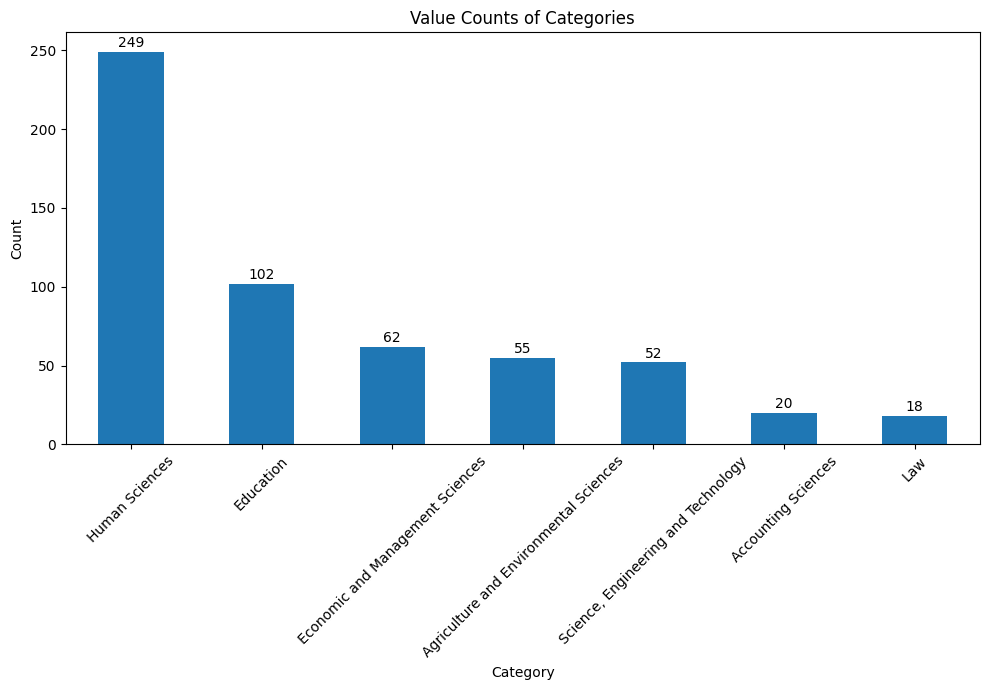

In [ ]:
import matplotlib.pyplot as plt

value_counts = features_df['faculty'].value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
bars = value_counts.plot(kind='bar', ax=ax, rot=45)

for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height-6),
                xytext=(0, 8),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_title('Value Counts of Categories')
ax.set_xlabel('Category')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


<h2>3. Feature - Target Split</h2>

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Fit Label encoder and return encoded labels
#y = y_balanced #features_df['faculty']
#X = X_balanced #features_df['features']
y = features_df['faculty']
X = features_df['features']
#type_labels = list(le.classes_)

<h2>4. Word2Vec Implementation</h2>

In [ ]:
import numpy as np
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.base import BaseEstimator, TransformerMixin

class Word2VecVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, word2vec_model):
        self.word2vec_model = word2vec_model
        self.vector_size = word2vec_model.vector_size

    def preprocess(self, text):
        text = text.lower()
        text = re.sub(r'[^a-zA-Z]+', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        words = word_tokenize(text)
        stop_words = set(stopwords.words('english'))
        filtered_words = [word for word in words if word not in stop_words]
        comments_words = ['purpose','may','required','skills','students','level',
                          'subject','internet','statement','rules','qualification']
        filtered_words = [word for word in filtered_words if word not in comments_words]
        return filtered_words

    def transform(self, raw_documents):
        embeddings = np.zeros((len(raw_documents), self.vector_size))

        for i, doc in enumerate(raw_documents):
            tokens = self.preprocess(doc)
            N_w = len(tokens)
            doc_emb = np.zeros((1, self.vector_size))

            for token in tokens:
                if token in self.word2vec_model:
                    vec = self.word2vec_model[token].reshape(1, -1)
                else:
                    vec = np.zeros((1, self.vector_size))
                doc_emb += vec

            if N_w == 0:
                N_w = 1  # Avoid division by zero
            embeddings[i] = doc_emb / N_w

        return embeddings

    def fit(self, X, y=None):
        return self


In [ ]:
import gensim.downloader
gensim_pretrains = list(gensim.downloader.info()['models'].keys())
model_i = 4 #ruscorpora(deja), glove-twitter-25 (deja), word2vec-google-news-300 (deja)
pretrain_model_name = gensim_pretrains[model_i-1]
word2vec_model = gensim.downloader.load(pretrain_model_name)

In [ ]:
# Assuming `word2vec_model` is already loaded
w2v_vectorizer = Word2VecVectorizer(word2vec_model)


X_train_raw = ['I am a child of God', 'the world is changing','group of fools']
X_test_raw = ['thieves','dawn']
# Apply to data
X_train_vec = w2v_vectorizer.fit_transform(X_train_raw)
X_test_vec = w2v_vectorizer.transform(X_test_raw)
X_test_vec.shape

(2, 300)

<h2>3. Crossvalidation </h2>

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define scoring metrics
# Updated scorers with zero_division=0
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

In [ ]:
"""
"XGBoost": grid_search_wrapper(
        XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        param_grid={
            'max_depth': [8,12,None]
        }
    )
"""

'\n"XGBoost": grid_search_wrapper(\n        XGBClassifier(use_label_encoder=False, eval_metric=\'mlogloss\', random_state=42),\n        param_grid={\n            \'max_depth\': [8,12,None]\n        }\n    )\n'

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
#from xgboost import XGBClassifier

def grid_search_wrapper(model, param_grid, scoring='f1_macro', cv=3):
    return GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

# List of classifiers to compare
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": grid_search_wrapper(
        DecisionTreeClassifier(random_state=42),
        param_grid={
            'max_depth': [8,12, None],
            'min_samples_leaf':[1,2,3]
        }
    )
    ,
    "MLP Classifier": grid_search_wrapper(
        MLPClassifier(max_iter=500, random_state=42,activation='relu'),
        param_grid={
            'hidden_layer_sizes': [(100,80), (120,100,80,50), (100,80,50,30)],
            'solver': ['adam']
        }
    )
}

In [ ]:
from sklearn.model_selection import StratifiedKFold
from collections import defaultdict
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.base import clone

# Optional: Enable or disable upsampling
apply_upsampling = False  # Set to False to disable

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Collect final results
final_results = []

# Store best instance (vectoriser + model) for each classifier
best_per_model = {}

# Iterate over classifiers
for model_name, clf in classifiers.items():
    print(f"\n====== {model_name} ======")

    metrics = defaultdict(list)
    all_conf_matrices = []

    best_f1 = -1
    best_model_instance = None
    best_vectoriser_instance = None

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        print(f"\n--- Fold {fold_idx} ---")
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Optional upsampling
        if apply_upsampling:
            df_train = pd.DataFrame({'text': X_train_raw, 'label': y_train})
            max_class_size = df_train['label'].value_counts().max()
            df_upsampled = pd.concat([
                resample(
                    df_train[df_train['label'] == label],
                    replace=True,
                    n_samples=max_class_size,
                    random_state=42
                )
                for label in df_train['label'].unique()
            ])
            df_upsampled = df_upsampled.sample(frac=1, random_state=42).reset_index(drop=True)
            X_train_raw = df_upsampled['text']
            y_train = df_upsampled['label']
            print(f"Applied upsampling: New training distribution:\n{y_train.value_counts()}")

        # Word2Vec Vectorisation
        w2v_vectorizer = Word2VecVectorizer(word2vec_model)
        X_train = w2v_vectorizer.fit_transform(X_train_raw)
        X_test = w2v_vectorizer.transform(X_test_raw)
        print("train",X_train.shape)
        print("test",X_test.shape)
        #print("Word2Vec Vocabulary size:", len(w2v_vectorizer.vocabulary_))

        #clf_instance = clf.__class__(**clf.get_params())
        clf_instance = clone(clf)
        clf_instance.fit(X_train, y_train)

        y_pred = clf_instance.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)

        print("Confusion Matrix:\n", cm)
        print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))

        metrics['Accuracy'].append(acc)
        metrics['Precision'].append(prec)
        metrics['Recall'].append(rec)
        metrics['F1-Score'].append(f1)
        all_conf_matrices.append(cm)

        if f1 > best_f1:
            best_f1 = f1
            best_model_instance = clf_instance
            best_vectoriser_instance = w2v_vectorizer

    avg_metrics = {k: np.mean(v) for k, v in metrics.items()}
    avg_metrics['Model'] = model_name
    final_results.append(avg_metrics)

    best_per_model[model_name] = {
        'f1': best_f1,
        'model': best_model_instance,
        'vectoriser': best_vectoriser_instance
    }

df_results = pd.DataFrame(final_results)
print("\n======= Final Averaged Results Across All Folds =======")
print(df_results)

print("\nBest fold per classifier (F1-score):")
for name, entry in best_per_model.items():
    print(f"{name}: F1 = {entry['f1']:.4f}")


====== Logistic Regression ======

--- Fold 1 ---
train (446, 300)
test (112, 300)
Confusion Matrix:
 [[ 0  0  3  1  0  0  0]
 [ 0  9  1  1  0  0  0]
 [ 0  0  8  1  4  0  0]
 [ 0  0  0 19  1  0  0]
 [ 0  0  0  0 50  0  0]
 [ 0  0  2  1  1  0  0]
 [ 0  2  0  0  3  0  5]]
Classification Report:
                                         precision    recall  f1-score   support

                   Accounting Sciences       0.00      0.00      0.00         4
Agriculture and Environmental Sciences       0.82      0.82      0.82        11
      Economic and Management Sciences       0.57      0.62      0.59        13
                             Education       0.83      0.95      0.88        20
                        Human Sciences       0.85      1.00      0.92        50
                                   Law       0.00      0.00      0.00         4
   Science, Engineering and Technology       1.00      0.50      0.67        10

                              accuracy                        

In [ ]:
# 1. Find the index of the row with the highest F1-score
best_idx = df_results['F1-Score'].idxmax()

# 2. Format numerical values to 4 decimal places
formatted_df = df_results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.4f}")

# 3. Convert to LaTeX with bold row
latex_lines = []
for idx, row in formatted_df.iterrows():
    row_str = " & ".join([f"\\textbf{{{v}}}" if idx == best_idx else str(v) for v in row])
    latex_lines.append(row_str + r" \\")

# 4. Build full LaTeX table
latex_table = r"""\begin{tabular}{lcccc}
\hline
Model & Accuracy & Precision & Recall & F1-Score \\
\hline
""" + "\n".join(latex_lines) + r"""
\hline
\end{tabular}
"""

# 5. Print LaTeX table
print(latex_table)

\begin{tabular}{lcccc}
\hline
Model & Accuracy & Precision & Recall & F1-Score \\
\hline
0.8351 & 0.5862 & 0.5779 & 0.5675 & Logistic Regression \\
0.9337 & 0.9298 & 0.8423 & 0.8617 & Linear SVM \\
0.9122 & 0.9231 & 0.7965 & 0.8219 & Random Forest \\
0.8081 & 0.6546 & 0.6516 & 0.6327 & Decision Tree \\
\textbf{0.9552} & \textbf{0.9318} & \textbf{0.9123} & \textbf{0.9118} & \textbf{MLP Classifier} \\
\hline
\end{tabular}



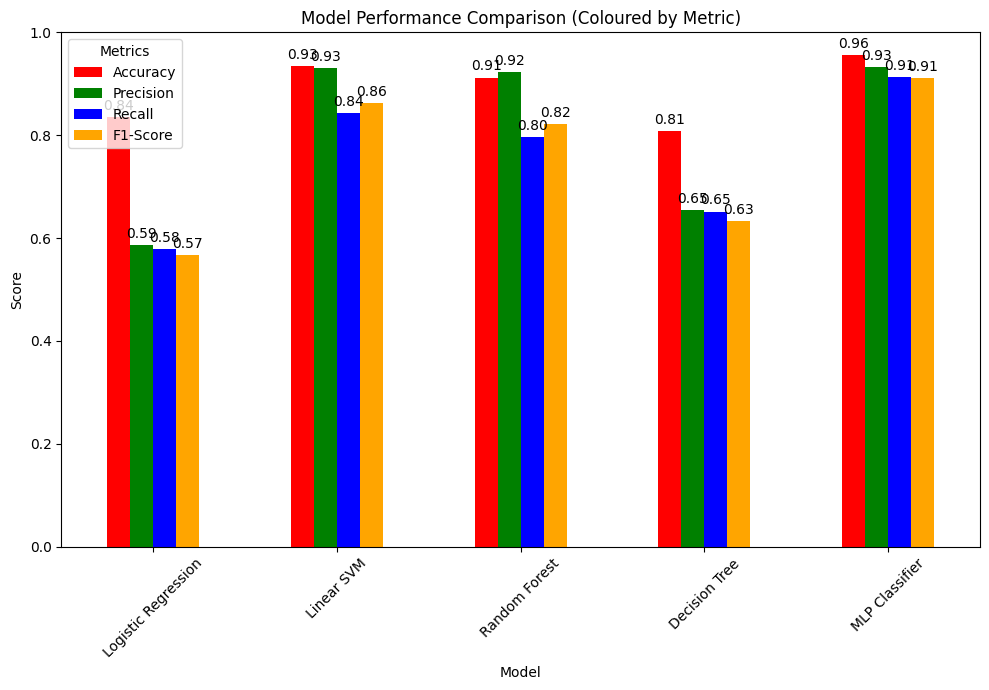

In [ ]:
# Set model as index
df_plot = df_results.set_index('Model')

# Define distinct colours for each metric
colors = ['red', 'green', 'blue', 'orange','black']

# Create bar chart
ax = df_plot.plot(kind='bar', figsize=(10, 7), color=colors)

# Add data labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Model Performance Comparison (Coloured by Metric)")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=45)
plt.grid(False, axis='y')
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

<h2>External Test Set</h2>

In [ ]:
user_df = pd.read_csv('/content/drive/MyDrive/Colab_Objects/data/user_test_survey.csv')
user_df.head(3)

,Timestamp,Which domain of study are you currently pursuing or have you completed?,Describe in a few paragraphs why you are/were interested in this field? (at least 100 words please).,"Which specific sub-domain within your field of interest would you like to pursue or have you pursued? For example, Electrical Engineering or Safety Management.",Any reasons why? At least 50 words please,What is your education level?
0,2024/12/03 4:17:47 pm EET,Human Sciences,I have always enjoyed learning about culture a...,I would like to purse a course in Psychology,To understand human behaviour and mental healt...,"Postgraduate level (Masters, Doctorate)"
1,2024/12/03 4:38:30 pm EET,"Social Work, Employment Relations and Human Re...",I am committed to making a meaningful impact o...,Research,This is a new and exciting career opportunity ...,"Postgraduate level (Masters, Doctorate)"
2,2024/12/03 4:47:56 pm EET,Education,Education is the driving point towards a bette...,I have Bed Degree Intermediate & Senior phase ...,Content is Data the ways in which is why it is...,"University graduate (Diploma, Advanced diploma..."


In [ ]:
test_df = user_df.iloc[:,[2,1]]
test_df.rename(columns={test_df.columns[0]: 'features', test_df.columns[1]: 'target'}, inplace=True)
test_df = test_df[test_df['target'].isin(y.unique())]#get only qualified targets
test_df['features'] = test_df['features'].apply(preprocess)
test_df.head()

,features,target
0,always enjoyed learning culture communication ...,Human Sciences
2,education driving point towards better south a...,Education
4,always interested psychopathology particularly...,Human Sciences
5,maintain environmental sustainability djdjdjdn...,Agriculture and Environmental Sciences
6,interested field information technology gives ...,"Science, Engineering and Technology"


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# External test dataset
external_data = test_df
# Initialize results
external_final_results = []
external_all_conf_matrices = []

# === 3. Evaluate each best model ===
for model_name, content in best_per_model.items():
    vec = content['vectoriser']
    model = content['model']
    # Transform external features
    X_ext = vec.transform(external_data['features'])
    y_true = external_data['target']
    y_pred = model.predict(X_ext)
    # === 4. Compute metrics ===
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n====== {model_name} ======")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    # Store results
    external_final_results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    external_all_conf_matrices.append(cm)

# === 6. Build results DataFrame ===
df_external_metrics = pd.DataFrame(external_final_results)
print("\nSummary Metrics:\n")
print(df_external_metrics)


====== Logistic Regression ======
Confusion Matrix:
 [[3 1 0 1 0 0]
 [0 2 1 0 0 0]
 [0 0 1 2 0 0]
 [1 1 0 4 0 0]
 [1 0 0 1 0 0]
 [1 3 0 7 0 6]]
Classification Report:
                                         precision    recall  f1-score   support

Agriculture and Environmental Sciences       0.50      0.60      0.55         5
      Economic and Management Sciences       0.29      0.67      0.40         3
                             Education       0.50      0.33      0.40         3
                        Human Sciences       0.27      0.67      0.38         6
                                   Law       0.00      0.00      0.00         2
   Science, Engineering and Technology       1.00      0.35      0.52        17

                              accuracy                           0.44        36
                             macro avg       0.43      0.44      0.37        36
                          weighted avg       0.65      0.44      0.45        36


====== Linear SVM ======
Co

In [ ]:
import pandas as pd
import pickle
from datetime import datetime
import os

# STEP 2: Define path in Google Drive
drive_path = '/content/drive/MyDrive/Colab_Objects/output'
os.makedirs(drive_path, exist_ok=True)  # Create if not exist

# Create DataFrames
df_results = pd.DataFrame(final_results)
df_external_metrics = pd.DataFrame(external_final_results)

# Print the results
print("\n======= Final Averaged Results Across All Folds =======")
print(df_results)

print("\n======= External Test Set Metrics =======")
print(df_external_metrics)

print("\nBest fold per classifier (F1-score):")
for name, entry in best_per_model.items():
    print(f"{name} {entry}")

# Generate timestamp
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# Define file names with timestamp
results_filename = os.path.join(drive_path,f"word2vec_df_results_{timestamp}.pkl")
best_model_filename = os.path.join(drive_path,f"word2vec_best_per_model_{timestamp}.pkl")
external_metrics_filename = os.path.join(drive_path,f"word2vec_external_metrics_{timestamp}.pkl")

# Save df_results
with open(results_filename, 'wb') as f:
    pickle.dump(df_results, f)

# Save best_per_model
with open(best_model_filename, 'wb') as f:
    pickle.dump(best_per_model, f)

# Save df_external_metrics
with open(external_metrics_filename, 'wb') as f:
    pickle.dump(df_external_metrics, f)

# Confirmation
print("\nFiles saved:")
print(f"- {results_filename}")
print(f"- {best_model_filename}")
print(f"- {external_metrics_filename}")



======= Final Averaged Results Across All Folds =======
   Accuracy  Precision    Recall  F1-Score                Model
0  0.835135   0.586239  0.577897  0.567499  Logistic Regression
1  0.933703   0.929825  0.842314  0.861684           Linear SVM
2  0.912162   0.923074  0.796476  0.821867        Random Forest
3  0.808140   0.654612  0.651603  0.632719        Decision Tree
4  0.955164   0.931784  0.912277  0.911808       MLP Classifier

======= External Test Set Metrics =======
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.444444   0.425397  0.436601  0.374691
1           Linear SVM  0.638889   0.676282  0.652288  0.640810
2        Random Forest  0.333333   0.476716  0.397386  0.313921
3        Decision Tree  0.222222   0.253247  0.216807  0.171252
4       MLP Classifier  0.750000   0.720238  0.783007  0.711691

Best fold per classifier (F1-score):
Logistic Regression {'f1': 0.6070074852683549, 'model': LogisticRegression(max_iter=1000), 've